# 6. LASSO - Regressão Logística com Regularização L1

## Descrição
O LASSO (Least Absolute Shrinkage and Selection Operator) é um modelo linear que realiza regularização L1, simultaneamente realizando seleção de características e classificação. A penalidade L1 força alguns coeficientes a exatamente zero, selecionando automaticamente as features mais relevantes para a predição. Neste trabalho, utilizamos a Regressão Logística com penalidade L1 como implementação do LASSO para classificação binária.

## Características
- Modelo linear com regularização L1 (penalidade no valor absoluto dos coeficientes)
- Realiza seleção de características automaticamente (coeficientes zero)
- Alta interpretabilidade: coeficientes indicam diretamente a importância e direção de cada feature
- Eficiente computacionalmente, escalável para grandes datasets
- Serve como baseline linear para comparação com modelos não-lineares

## Referências
- Tibshirani, R. (1996). Regression Shrinkage and Selection via the Lasso. Journal of the Royal Statistical Society, Series B, 58(1), 267-288.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning. Springer.

## 1. Importações e Configurações

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score, accuracy_score,
    precision_score, recall_score, auc
)
import joblib

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

os.makedirs('../graficos', exist_ok=True)
os.makedirs('../modelos', exist_ok=True)

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 2. Carregamento dos Dados Pré-processados

In [33]:
with open('../dados/processados/datasets.pkl', 'rb') as f:
    datasets = pickle.load(f)

X_train = datasets['baseline']['X_train']
X_val = datasets['baseline']['X_val']
X_test = datasets['baseline']['X_test']
y_train = datasets['baseline']['y_train']
y_val = datasets['baseline']['y_val']
y_test = datasets['baseline']['y_test']

print(f'Dataset carregado: {datasets["baseline"]["descricao"]}')
print(f'\nDimensões:')
print(f'  X_train: {X_train.shape}')
print(f'  X_val: {X_val.shape}')
print(f'  X_test: {X_test.shape}')
print(f'\nDistribuição de classes (treino): {y_train.value_counts().to_dict()}')

Dataset carregado: Mediana + StandardScaler + SelectKBest

Dimensões:
  X_train: (1730, 50)
  X_val: (372, 50)
  X_test: (372, 50)

Distribuição de classes (treino): {1: 952, 0: 778}


## 3. Otimização de Hiperparâmetros com Random Search

In [34]:
# class_weight obrigatório: None leva a prever APENAS supercondutor (classe 1)
param_dist = {
    'C': [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000, 2000, 5000, 10000],
    'class_weight': ['balanced', {0: 1.5, 1: 1}, {0: 2, 1: 1}],  # SEM None - força predição das 2 classes
    'tol': [1e-4, 1e-3, 1e-2]
}

lasso_base = LogisticRegression(penalty='l1', random_state=42)

random_search = RandomizedSearchCV(
    lasso_base,
    param_dist,
    n_iter=80,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print('Iniciando Random Search para LASSO...')
random_search.fit(X_train, y_train)

print(f'\nMelhores hiperparâmetros encontrados:')
for param, value in random_search.best_params_.items():
    print(f'  {param}: {value}')
print(f'\nMelhor F1-score (validação cruzada): {random_search.best_score_:.4f}')

Iniciando Random Search para LASSO...
Fitting 5 folds for each of 80 candidates, totalling 400 fits

Melhores hiperparâmetros encontrados:
  tol: 0.001
  solver: saga
  max_iter: 1000
  class_weight: balanced
  C: 0.5

Melhor F1-score (validação cruzada): 0.6058


## 4. Treinamento do Modelo Otimizado

In [35]:
lasso_model = random_search.best_estimator_

# Avaliar no conjunto de validação
y_val_pred = lasso_model.predict(X_val)
y_val_pred_proba = lasso_model.predict_proba(X_val)[:, 1]

# Avaliar no conjunto de teste
y_test_pred = lasso_model.predict(X_test)
y_test_pred_proba = lasso_model.predict_proba(X_test)[:, 1]

print('Modelo LASSO treinado com sucesso!')

Modelo LASSO treinado com sucesso!


## 5. Avaliação do Modelo

In [36]:
# Métricas no conjunto de validação
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, y_val_pred_proba)

# Métricas no conjunto de teste
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_pred_proba)
test_pr_auc = auc(recall_vals, precision_vals)

print('=' * 70)
print('MÉTRICAS DE DESEMPENHO - LASSO (Regressão Logística L1)')
print('=' * 70)
print(f'\nCONJUNTO DE VALIDAÇÃO:')
print(f'  Acurácia:  {val_accuracy:.4f}')
print(f'  Precisão:  {val_precision:.4f}')
print(f'  Recall:    {val_recall:.4f}')
print(f'  F1-Score:  {val_f1:.4f}')
print(f'  ROC-AUC:   {val_roc_auc:.4f}')
print(f'\nCONJUNTO DE TESTE:')
print(f'  Acurácia:  {test_accuracy:.4f}')
print(f'  Precisão:  {test_precision:.4f}')
print(f'  Recall:    {test_recall:.4f}')
print(f'  F1-Score:  {test_f1:.4f}')
print(f'  ROC-AUC:   {test_roc_auc:.4f}')
print(f'  PR-AUC:    {test_pr_auc:.4f}')
print('=' * 70)

MÉTRICAS DE DESEMPENHO - LASSO (Regressão Logística L1)

CONJUNTO DE VALIDAÇÃO:
  Acurácia:  0.5511
  Precisão:  0.6092
  Recall:    0.5171
  F1-Score:  0.5594
  ROC-AUC:   0.5729

CONJUNTO DE TESTE:
  Acurácia:  0.5833
  Precisão:  0.6276
  Recall:    0.6000
  F1-Score:  0.6135
  ROC-AUC:   0.6143
  PR-AUC:    0.6313


In [37]:
# Relatório de classificação detalhado
print('\nRELATÓRIO DE CLASSIFICAÇÃO (Conjunto de Teste):')
print(classification_report(y_test, y_test_pred, target_names=['Não-Supercondutor', 'Supercondutor']))


RELATÓRIO DE CLASSIFICAÇÃO (Conjunto de Teste):
                   precision    recall  f1-score   support

Não-Supercondutor       0.53      0.56      0.55       167
    Supercondutor       0.63      0.60      0.61       205

         accuracy                           0.58       372
        macro avg       0.58      0.58      0.58       372
     weighted avg       0.59      0.58      0.58       372



## 6. Visualizações de Desempenho

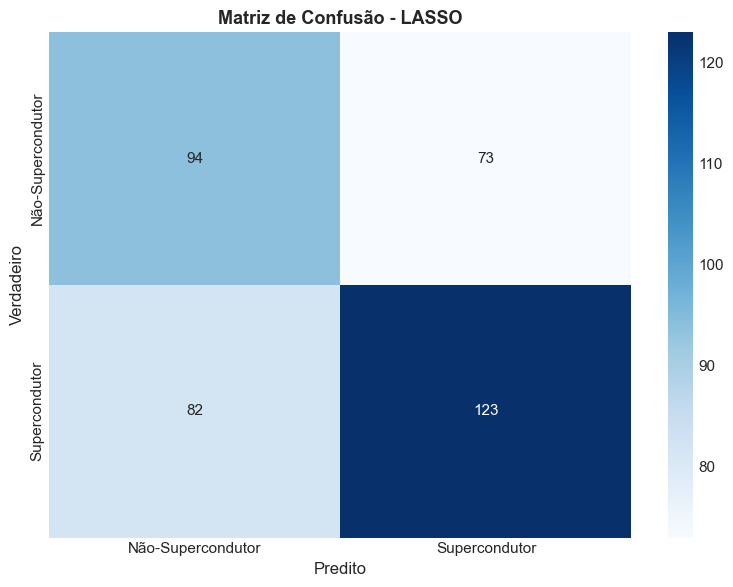

Gráfico salvo: ../graficos/06_lasso_confusion_matrix.png


In [38]:
# 6.1 Matriz de Confusão
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
            xticklabels=['Não-Supercondutor', 'Supercondutor'],
            yticklabels=['Não-Supercondutor', 'Supercondutor'])
ax.set_ylabel('Verdadeiro', fontsize=12)
ax.set_xlabel('Predito', fontsize=12)
ax.set_title('Matriz de Confusão - LASSO', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../graficos/06_lasso_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/06_lasso_confusion_matrix.png')

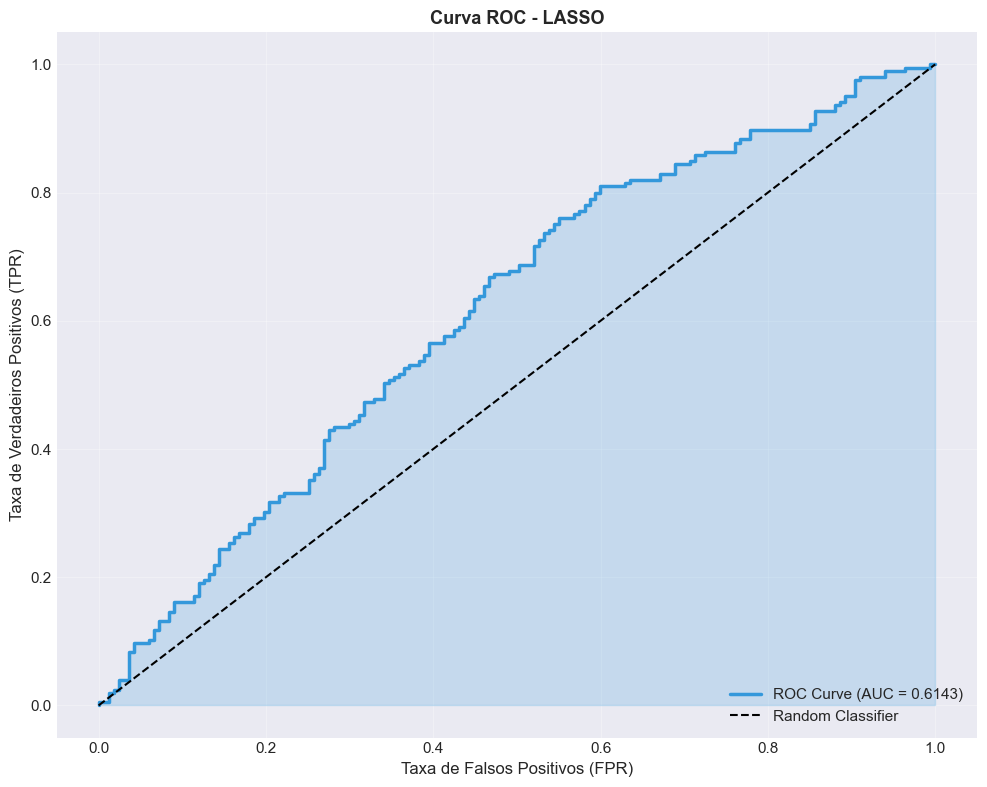

Gráfico salvo: ../graficos/06_lasso_roc_curve.png


In [39]:
# 6.2 Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fpr, tpr, label=f'ROC Curve (AUC = {test_roc_auc:.4f})', linewidth=2.5, color='#3498DB')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='#3498DB')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('Curva ROC - LASSO', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../graficos/06_lasso_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/06_lasso_roc_curve.png')

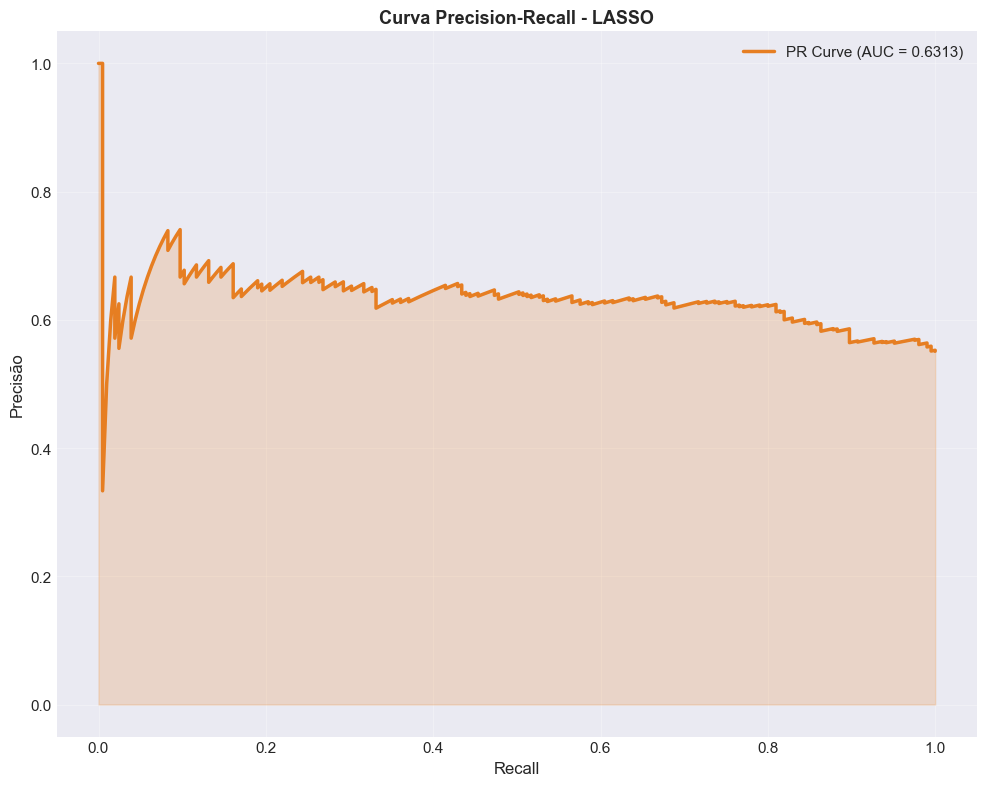

Gráfico salvo: ../graficos/06_lasso_pr_curve.png


In [40]:
# 6.3 Curva Precision-Recall
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_test_pred_proba)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(recall_curve, precision_curve, label=f'PR Curve (AUC = {test_pr_auc:.4f})', linewidth=2.5, color='#E67E22')
ax.fill_between(recall_curve, precision_curve, alpha=0.2, color='#E67E22')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precisão', fontsize=12)
ax.set_title('Curva Precision-Recall - LASSO', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../graficos/06_lasso_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/06_lasso_pr_curve.png')

## 7. Análise de Coeficientes e Seleção de Features

In [41]:
# Análise dos coeficientes do modelo
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lasso_model.coef_[0],
    'abs_coefficient': np.abs(lasso_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

n_nonzero = (lasso_model.coef_[0] != 0).sum()
n_total = len(lasso_model.coef_[0])

print('=' * 70)
print('ANÁLISE DE COEFICIENTES - LASSO')
print('=' * 70)
print(f'\nFeatures com coeficiente não-zero: {n_nonzero} de {n_total} ({100*n_nonzero/n_total:.1f}%)')
print(f'Features eliminadas (coeficiente = 0): {n_total - n_nonzero}')
print(f'\nTop 15 Features por importância (|coeficiente|):')
print(coef_df[['feature', 'coefficient', 'abs_coefficient']].head(15).to_string(index=False))

ANÁLISE DE COEFICIENTES - LASSO

Features com coeficiente não-zero: 43 de 50 (86.0%)
Features eliminadas (coeficiente = 0): 7

Top 15 Features por importância (|coeficiente|):
       feature  coefficient  abs_coefficient
  sc_bands_max     0.277465         0.277465
fermi_line_std    -0.272192         0.272192
  position_1_0     0.251282         0.251282
  position_5_0    -0.206966         0.206966
recip_latt_1_0     0.206514         0.206514
  position_6_2    -0.159423         0.159423
   sc_DOSs_max     0.157166         0.157166
  position_4_1     0.149969         0.149969
 position_12_1    -0.137231         0.137231
  position_7_2     0.131054         0.131054
  fermi_lens_1     0.123195         0.123195
  position_8_2     0.119936         0.119936
  sc_DOSs_mean     0.107261         0.107261
 position_10_1    -0.104722         0.104722
      cell_0_0     0.102862         0.102862


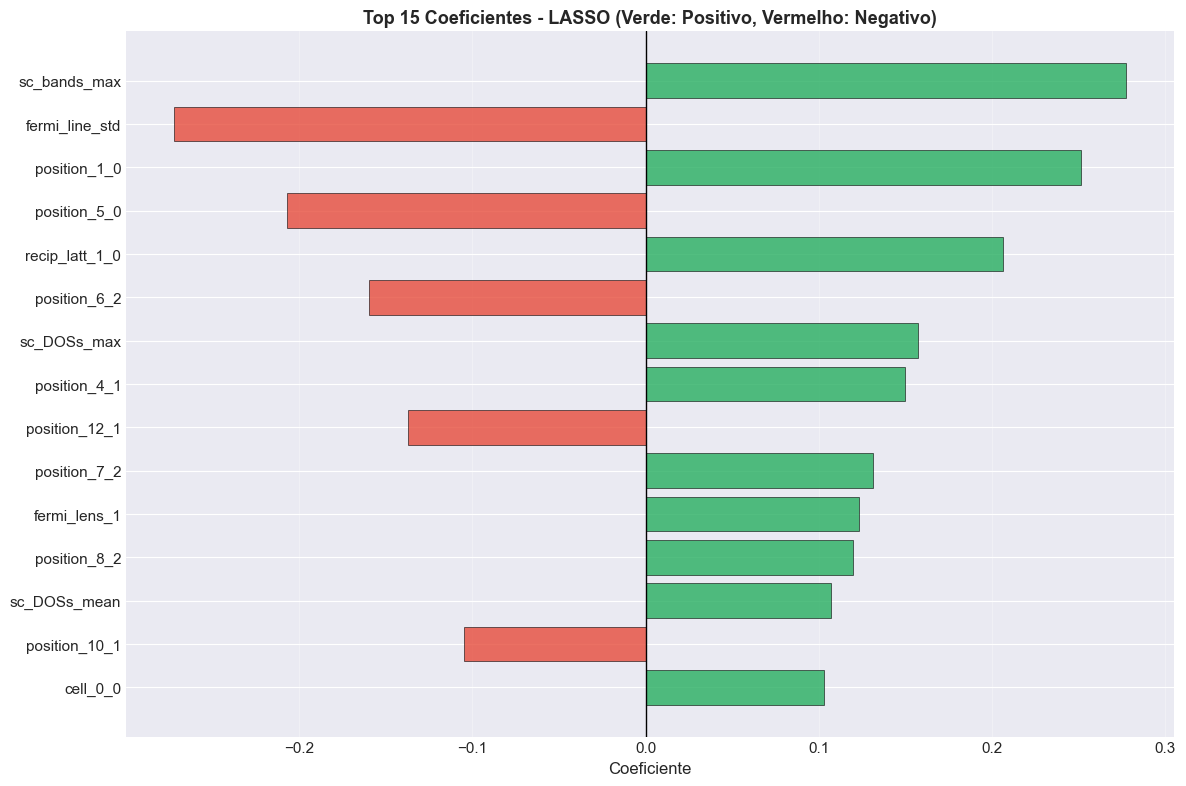

Gráfico salvo: ../graficos/06_lasso_coefficients.png


In [42]:
# 7.1 Gráfico de Coeficientes (Top 15)
fig, ax = plt.subplots(figsize=(12, 8))
top_coef = coef_df.head(15)
colors = ['#27AE60' if c > 0 else '#E74C3C' for c in top_coef['coefficient'].values]
ax.barh(range(len(top_coef)), top_coef['coefficient'].values, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(top_coef)))
ax.set_yticklabels(top_coef['feature'].values)
ax.set_xlabel('Coeficiente', fontsize=12)
ax.set_title('Top 15 Coeficientes - LASSO (Verde: Positivo, Vermelho: Negativo)', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../graficos/06_lasso_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/06_lasso_coefficients.png')

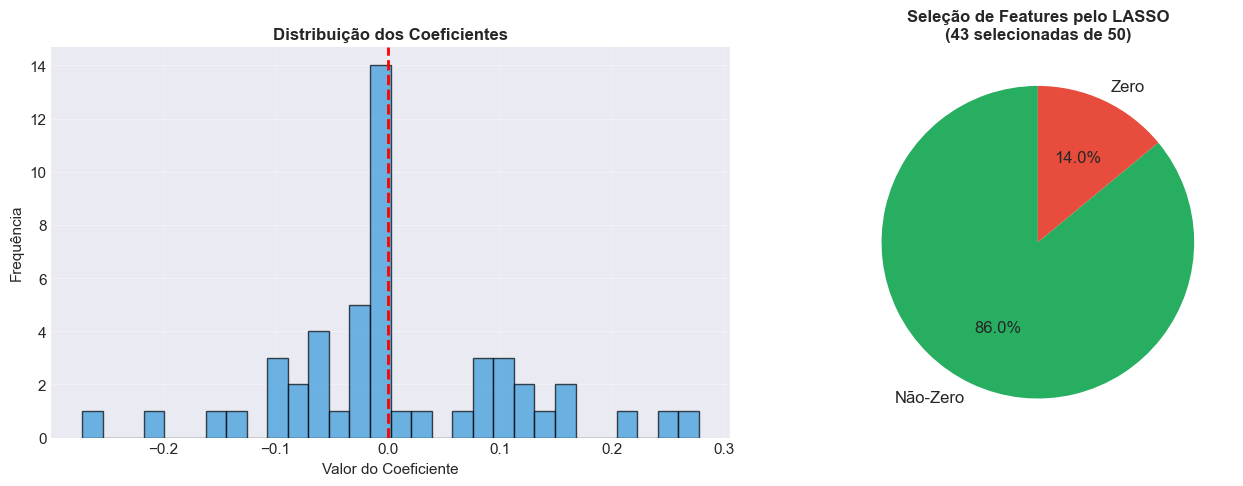

Gráfico salvo: ../graficos/06_lasso_coef_distribution.png


In [43]:
# 7.2 Distribuição dos Coeficientes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de todos os coeficientes
ax1 = axes[0]
ax1.hist(lasso_model.coef_[0], bins=30, color='#3498DB', alpha=0.7, edgecolor='black')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Valor do Coeficiente', fontsize=11)
ax1.set_ylabel('Frequência', fontsize=11)
ax1.set_title('Distribuição dos Coeficientes', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)

# Coeficientes não-zero vs zero
ax2 = axes[1]
labels = ['Não-Zero', 'Zero']
sizes = [n_nonzero, n_total - n_nonzero]
colors_pie = ['#27AE60', '#E74C3C']
ax2.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
ax2.set_title(f'Seleção de Features pelo LASSO\n({n_nonzero} selecionadas de {n_total})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../graficos/06_lasso_coef_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/06_lasso_coef_distribution.png')

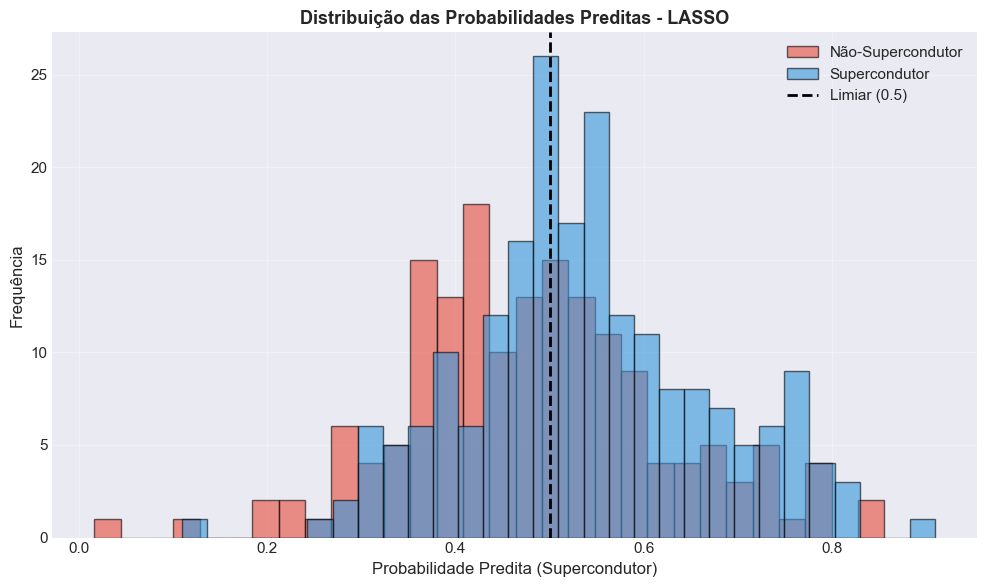

Gráfico salvo: ../graficos/06_lasso_prob_distribution.png


In [44]:
# 7.3 Distribuição das Probabilidades Preditas
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(y_test_pred_proba[y_test == 0], bins=30, alpha=0.6, color='#E74C3C', label='Não-Supercondutor', edgecolor='black')
ax.hist(y_test_pred_proba[y_test == 1], bins=30, alpha=0.6, color='#3498DB', label='Supercondutor', edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Limiar (0.5)')
ax.set_xlabel('Probabilidade Predita (Supercondutor)', fontsize=12)
ax.set_ylabel('Frequência', fontsize=12)
ax.set_title('Distribuição das Probabilidades Preditas - LASSO', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../graficos/06_lasso_prob_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/06_lasso_prob_distribution.png')

## 8. Salvamento do Modelo e Resultados

In [45]:
# Salvar modelo treinado
joblib.dump(lasso_model, '../modelos/lasso_model.pkl')

# Salvar resultados em dicionário
results = {
    'model_name': 'LASSO',
    'best_params': random_search.best_params_,
    'metrics': {
        'val_accuracy': val_accuracy,
        'val_precision': val_precision,
        'val_recall': val_recall,
        'val_f1': val_f1,
        'val_roc_auc': val_roc_auc,
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'test_roc_auc': test_roc_auc,
        'test_pr_auc': test_pr_auc
    },
    'feature_importance': coef_df,
    'predictions': {
        'y_test_pred': y_test_pred,
        'y_test_pred_proba': y_test_pred_proba
    }
}

with open('../modelos/lasso_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print('Modelo e resultados salvos com sucesso!')
print(f'  - Modelo: ../modelos/lasso_model.pkl')
print(f'  - Resultados: ../modelos/lasso_results.pkl')

Modelo e resultados salvos com sucesso!
  - Modelo: ../modelos/lasso_model.pkl
  - Resultados: ../modelos/lasso_results.pkl


## 9. Conclusões e Próximas Etapas

In [46]:
print('=' * 70)
print('RESUMO - LASSO (Regressão Logística com Regularização L1)')
print('=' * 70)
print(f'\nDesempenho no Conjunto de Teste:')
print(f'  F1-Score:  {test_f1:.4f}')
print(f'  ROC-AUC:   {test_roc_auc:.4f}')
print(f'  Acurácia:  {test_accuracy:.4f}')
print(f'  Precisão:  {test_precision:.4f}')
print(f'  Recall:    {test_recall:.4f}')
print(f'  PR-AUC:    {test_pr_auc:.4f}')
print(f'\nSeleção de Features:')
print(f'  Features selecionadas: {n_nonzero} de {n_total}')
print(f'  Features eliminadas: {n_total - n_nonzero}')
print(f'\nTop 5 Features (por |coeficiente|):')
for _, row in coef_df.head(5).iterrows():
    direction = '+' if row['coefficient'] > 0 else '-'
    print(f'  [{direction}] {row["feature"]}: {row["coefficient"]:.4f}')
print(f'\nObservações:')
print(f'  - O LASSO serve como baseline linear para o problema de classificação')
print(f'  - O desempenho inferior aos modelos não-lineares confirma a complexidade do problema')
print(f'  - A seleção de features pelo LASSO identifica os descritores mais relevantes')
print(f'  - Coeficientes positivos indicam features que favorecem a supercondutividade')
print(f'  - Coeficientes negativos indicam features que desfavorecem a supercondutividade')
print('\n' + '=' * 70)
print('Próxima etapa: Análise Comparativa de todos os modelos')
print('=' * 70)

RESUMO - LASSO (Regressão Logística com Regularização L1)

Desempenho no Conjunto de Teste:
  F1-Score:  0.6135
  ROC-AUC:   0.6143
  Acurácia:  0.5833
  Precisão:  0.6276
  Recall:    0.6000
  PR-AUC:    0.6313

Seleção de Features:
  Features selecionadas: 43 de 50
  Features eliminadas: 7

Top 5 Features (por |coeficiente|):
  [+] sc_bands_max: 0.2775
  [-] fermi_line_std: -0.2722
  [+] position_1_0: 0.2513
  [-] position_5_0: -0.2070
  [+] recip_latt_1_0: 0.2065

Observações:
  - O LASSO serve como baseline linear para o problema de classificação
  - O desempenho inferior aos modelos não-lineares confirma a complexidade do problema
  - A seleção de features pelo LASSO identifica os descritores mais relevantes
  - Coeficientes positivos indicam features que favorecem a supercondutividade
  - Coeficientes negativos indicam features que desfavorecem a supercondutividade

Próxima etapa: Análise Comparativa de todos os modelos
